In [1]:
from scipy.stats import ks_2samp, gaussian_kde, wasserstein_distance
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from factor_model import load_model
from metrics.statistic import compute_cov
from scenario_generator import *
import yaml

with open("cfg.yaml") as f:
    _exp = yaml.safe_load(f)["experiment_name"]
PREFIX = f"model/{_exp}"
with open(f"{PREFIX}/cfg.yaml") as f:
    _cfg = yaml.safe_load(f)

FACTOR_NAMES = _cfg["factor_names"]
NUM_GENERATE = _cfg["num_generate"]

In [2]:
model = load_model(PREFIX)
test_model = load_model(f"{PREFIX}/test")
print(PREFIX)

model/regression


In [3]:
diffusionScenario = ScenarioGenerator(model, DiffusionSampler(f"{PREFIX}/checkpoints/{_cfg['ckpt_name']}.pt"))

/home/renyi/anaconda3/envs/diffusion_factor_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
scaler = diffusionScenario.sampler.scaler
sampled = diffusionScenario.factor_generate(NUM_GENERATE)
sampled.shape

(4096, 7)

In [5]:
# training ds
train = model.F

# get the resampled baseline
gaussionScenario = ScenarioGenerator(model, GaussianSampler(train, scaler))
sampled_gaussian = gaussionScenario.factor_generate(NUM_GENERATE)

# test ds
OOS = test_model.F.drop(columns=['alpha']).values

# resample baseline
resampleScenario = ScenarioGenerator(model, ResampleSampler(train, diffusionScenario.sampler.scaler))
resample = resampleScenario.factor_generate(NUM_GENERATE)


baselines = [("Resample", resample, '#17becf'), ("Gaussion", sampled_gaussian, '#ff7f0e')]
print(f"OOS: {OOS.shape}  sampled: {sampled.shape}  Gaussian: {sampled_gaussian.shape}")

OOS: (260, 7)  sampled: (4096, 7)  Gaussian: (4096, 7)


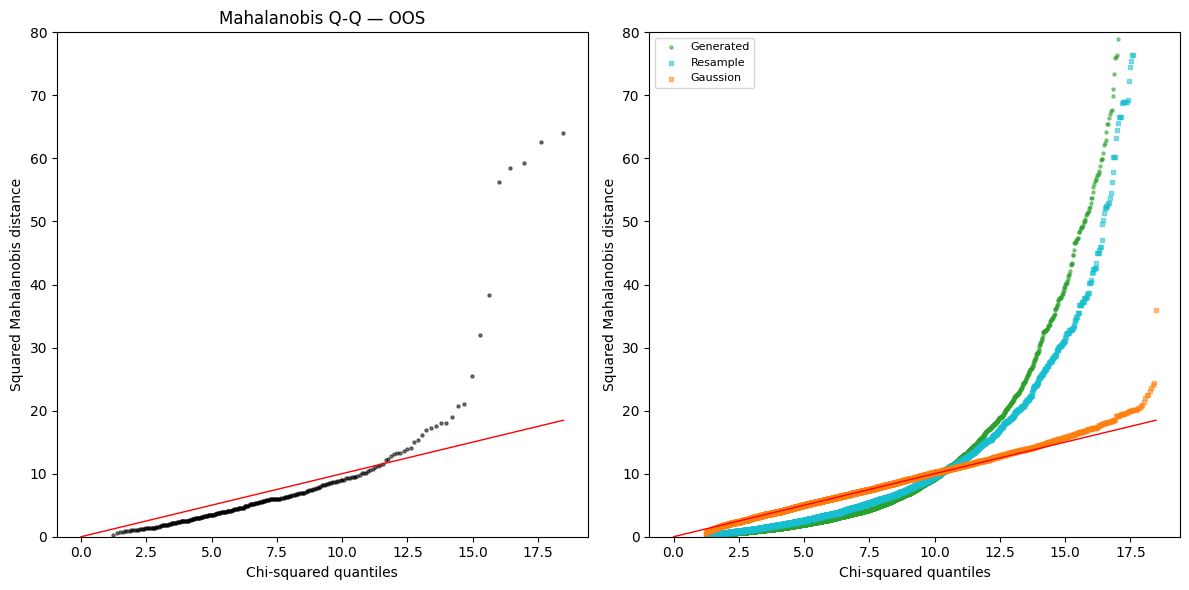

In [6]:
# 2.0 Mahalanobis check
def mahal_d2(X):
    mean = X.mean(axis=0)
    cov  = np.cov(X, rowvar=False)
    diff = X - mean
    return (diff @ np.linalg.pinv(cov) * diff).sum(axis=1)

def plot_mahal(ax, X, label, color='steelblue', marker='o', size=5, alpha=0.5):
    p  = X.shape[1]
    d2 = mahal_d2(X)
    qs = stats.chi2.ppf(np.linspace(0.01, 0.99, len(d2)), df=p)
    ax.scatter(qs, np.sort(d2), s=size, alpha=alpha, color=color,
               marker=marker, label=label)
    return qs.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Left panel: OOS
q_max = plot_mahal(ax1, OOS, 'OOS', color='black')
ax1.plot([0, q_max], [0, q_max], color='red', linewidth=1)
ax1.set_ylim(0, 80)
ax1.set_xlabel('Chi-squared quantiles')
ax1.set_ylabel('Squared Mahalanobis distance')
ax1.set_title('Mahalanobis Q-Q — OOS')

# Right panel: Generated + Baselines overlaid
q_max2 = plot_mahal(ax2, sampled, 'Generated', color='#2ca02c')
for (bname, bdata, bc) in baselines:
    q_max2 = max(q_max2, plot_mahal(ax2, bdata, bname, color=bc, marker='s'))
ax2.plot([0, q_max2], [0, q_max2], color='red', linewidth=1)
ax2.set_ylim(0, 80)
ax2.set_xlabel('Chi-squared quantiles'); ax2.set_ylabel('Squared Mahalanobis distance')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

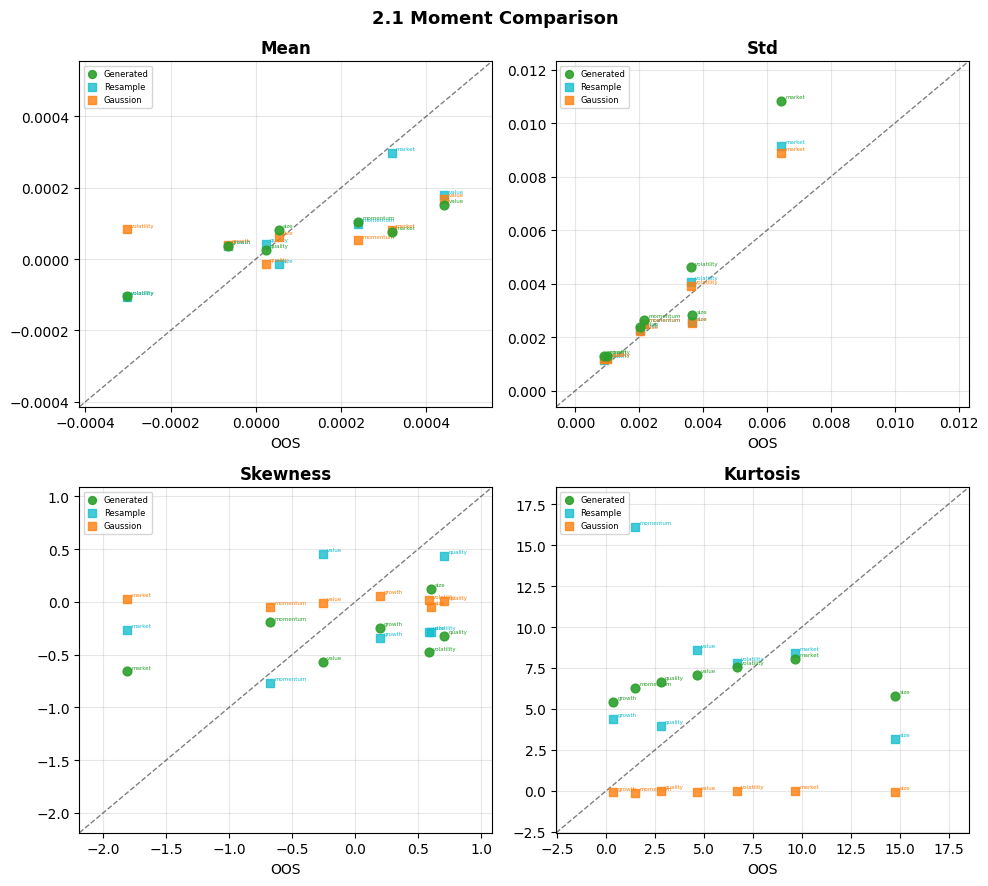

In [7]:
# 2.1 Moment Comparison
def compute_moments(data):
    return [np.mean(data, axis=0), np.std(data, axis=0),
            stats.skew(data, axis=0), stats.kurtosis(data, axis=0)]


moment_names = ['Mean', 'Std', 'Skewness', 'Kurtosis']
m_OOS    = compute_moments(OOS)
m_gen    = compute_moments(sampled)
m_bases  = [(name, compute_moments(data), c) for name, data, c in baselines]

ANNOT_FS = 4
LEGEND_FS = 6
PT_SIZE   = 40

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for idx, (ax, mname) in enumerate(zip(axes.flatten(), moment_names)):
    OOS_m = m_OOS[idx]
    gen_m = m_gen[idx]
    all_y = [gen_m] + [bm[idx] for _, bm, _ in m_bases]

    lim = [min(OOS_m.min(), min(y.min() for y in all_y)),
           max(OOS_m.max(), max(y.max() for y in all_y))]
    pad = (lim[1] - lim[0]) * 0.15 or 0.01
    lim = [lim[0] - pad, lim[1] + pad]

    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)
    ax.scatter(OOS_m, gen_m, color='#2ca02c', s=PT_SIZE, marker='o', zorder=4,
               label='Generated', alpha=0.9)
    for i, fn in enumerate(FACTOR_NAMES):
        ax.annotate(fn, (OOS_m[i], gen_m[i]), fontsize=ANNOT_FS,
                    xytext=(3, 2), textcoords='offset points', color='#2ca02c')
    for (bname, bm, bc) in m_bases:
        ax.scatter(OOS_m, bm[idx], color=bc, s=PT_SIZE, marker='s', zorder=3,
                   label=bname, alpha=0.8)
        for i, fn in enumerate(FACTOR_NAMES):
            ax.annotate(fn, (OOS_m[i], bm[idx][i]), fontsize=ANNOT_FS,
                        xytext=(3, 2), textcoords='offset points', color=bc)

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('OOS')
    ax.set_title(mname, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEGEND_FS, markerscale=0.9, handlelength=1.2)

fig.suptitle('2.1 Moment Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
def fmt_mae(errs):
    return f"{np.mean(errs):.4f} ({np.std(errs):.4f})"

col_w = 22
header = f"{'Moment':<12}" + f"{'Generated':<{col_w}}" + \
         "".join(f"{bname:<{col_w}}" for bname, _, _ in m_bases)
print("MAE across factors — mean (std):")
print(header)
print("-" * len(header))
for idx, mname in enumerate(moment_names):
    row = f"{mname:<12}{fmt_mae(np.abs(m_gen[idx] - m_OOS[idx])):<{col_w}}"
    for _, bm, _ in m_bases:
        row += f"{fmt_mae(np.abs(bm[idx] - m_OOS[idx])):<{col_w}}"
    print(row)

MAE across factors — mean (std):
Moment      Generated             Resample              Gaussion              
------------------------------------------------------------------------------
Mean        0.0001 (0.0001)       0.0001 (0.0001)       0.0002 (0.0001)       
Std         0.0011 (0.0014)       0.0008 (0.0008)       0.0007 (0.0008)       
Skewness    0.7085 (0.3295)       0.7015 (0.4400)       0.6804 (0.5124)       
Kurtosis    3.9522 (2.5222)       5.3961 (5.0843)       5.8258 (4.6930)       


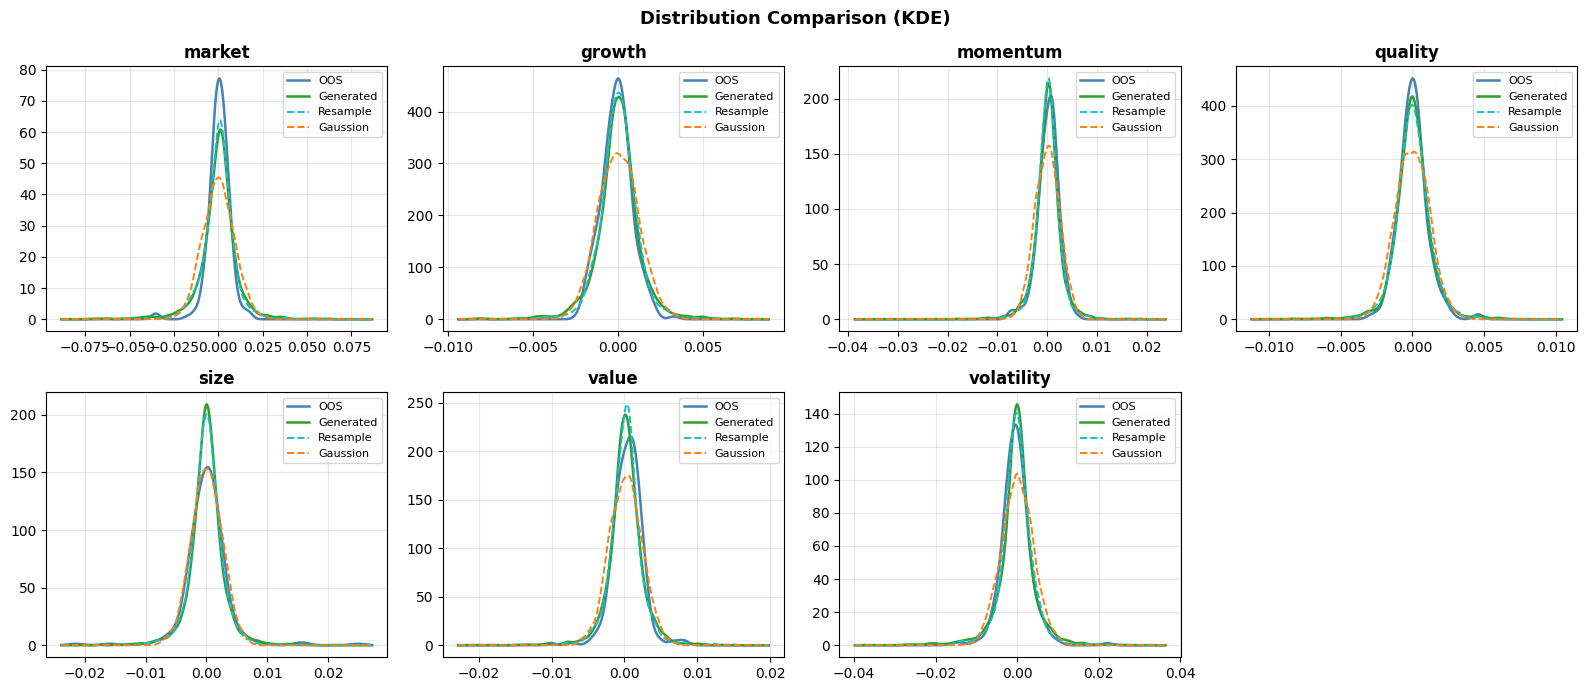

In [9]:
#Distribution Comparison (KDE)
n_factors = len(FACTOR_NAMES)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, name, i in zip(axes.flatten(), FACTOR_NAMES, range(n_factors)):
    OOS_vals    = OOS[:, i]
    gen_vals    = sampled[:, i]

    all_vals = np.concatenate([OOS_vals, gen_vals] +
                              [bdata[:, i] for _, bdata, _ in baselines])
    x_min, x_max = all_vals.min(), all_vals.max()
    pad = (x_max - x_min) * 0.05
    x = np.linspace(x_min - pad, x_max + pad, 300)

    for vals, label, color, ls, lw in [
        (OOS_vals,   'OOS',       'steelblue', '-', 1.8),
        (gen_vals,   'Generated', '#2ca02c',     '-', 1.8),
    ]:
        ax.plot(x, gaussian_kde(vals)(x), label=label, color=color, lw=lw, ls=ls)

    for (bname, bdata, bc) in baselines:
        ax.plot(x, gaussian_kde(bdata[:, i])(x),
                label=bname, color=bc, lw=1.4, ls='--')

    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes.flatten()[n_factors:]:
    ax.set_visible(False)

fig.suptitle('Distribution Comparison (KDE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
col_w = 14
header = f"{'Factor':<14}" + f"{'Generated':<{col_w}}" + \
         "".join(f"{bname:<{col_w}}" for bname, _, _ in baselines)
print("Wasserstein-1 Distance:")
print(header)
print("-" * len(header))
for i, name in enumerate(FACTOR_NAMES):
    w1_gen = wasserstein_distance(OOS[:, i], sampled[:, i])
    row = f"{name:<14}{w1_gen:<{col_w}.4f}"
    for _, bdata, _ in baselines:
        row += f"{wasserstein_distance(OOS[:, i], bdata[:, i]):<{col_w}.4f}"
    print(row)
avg_gen = np.mean([wasserstein_distance(OOS[:, i], sampled[:, i]) for i in range(n_factors)])
avgs_b  = [np.mean([wasserstein_distance(OOS[:, i], bdata[:, i]) for i in range(n_factors)])
           for _, bdata, _ in baselines]

Wasserstein-1 Distance:
Factor        Generated     Resample      Gaussion      
--------------------------------------------------------
market        0.0026        0.0020        0.0031        
growth        0.0003        0.0002        0.0003        
momentum      0.0003        0.0003        0.0005        
quality       0.0002        0.0001        0.0002        
size          0.0004        0.0004        0.0005        
value         0.0004        0.0004        0.0005        
volatility    0.0007        0.0005        0.0008        


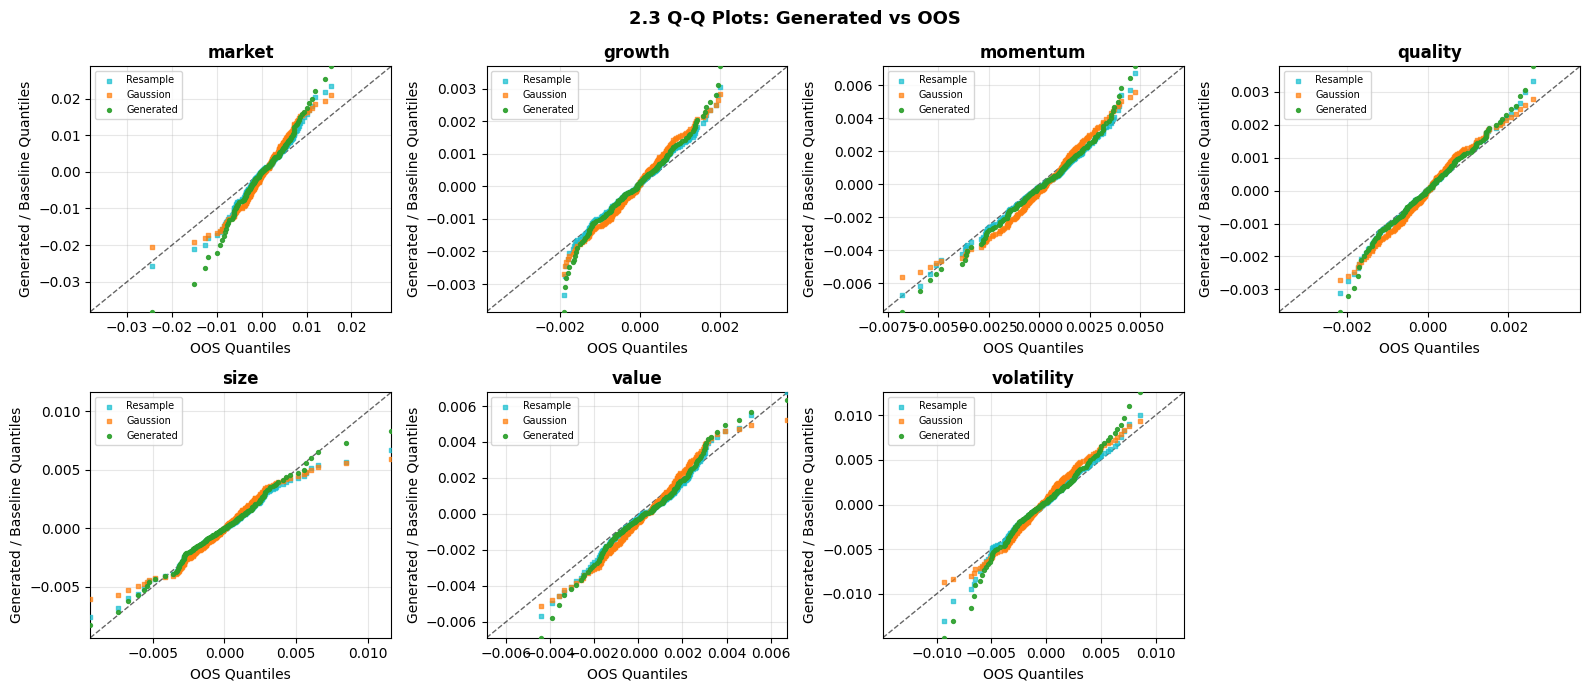

In [11]:
# Quantile-Quantile (Q-Q) Plots
n_quantiles = 200
probs = np.linspace(0.01, 0.99, n_quantiles)
n_factors = len(FACTOR_NAMES)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, name, i in zip(axes.flatten(), FACTOR_NAMES, range(n_factors)):
    q_OOS  = np.quantile(OOS[:, i],      probs)
    q_gen  = np.quantile(sampled[:, i],  probs)

    all_q = [q_OOS, q_gen] + [np.quantile(bdata[:, i], probs) for _, bdata, _ in baselines]
    lim = [min(q.min() for q in all_q), max(q.max() for q in all_q)]

    for (bname, bdata, bc) in baselines:
        q_base = np.quantile(bdata[:, i], probs)
        ax.scatter(q_OOS, q_base, s=8, color=bc, zorder=3,
                   label=bname, alpha=0.7, marker='s')

    ax.scatter(q_OOS, q_gen, s=8, color='#2ca02c', zorder=4, label='Generated', alpha=0.9)

    ax.plot(lim, lim, 'k--', lw=1, alpha=0.6)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('OOS Quantiles')
    ax.set_ylabel('Generated / Baseline Quantiles')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# hide unused subplots
for ax in axes.flatten()[n_factors:]:
    ax.set_visible(False)

fig.suptitle('2.3 Q-Q Plots: Generated vs OOS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# KS Test
ks_gen   = [ks_2samp(OOS[:, i], sampled[:, i]).pvalue for i in range(len(FACTOR_NAMES))]
ks_bases = [(bname, [ks_2samp(OOS[:, i], bdata[:, i]).pvalue
                     for i in range(len(FACTOR_NAMES))])
            for bname, bdata, _ in baselines]

col_w = 16
header = f"{'Factor':<18} {'Generated':<{col_w}}" + \
         "".join(f"{bname:<{col_w}}" for bname, _ in ks_bases)
print(f"KS p-value")
print(header)
print("-" * len(header))
for j, name in enumerate(FACTOR_NAMES):
    row = f"{name:<18} {ks_gen[j]:<{col_w}.4f}"
    for _, bks in ks_bases:
        row += f"{bks[j]:<{col_w}.4f}"
    print(row)

KS p-value
Factor             Generated       Resample        Gaussion        
-------------------------------------------------------------------
market             0.0079          0.0174          0.0000          
growth             0.0690          0.0637          0.0003          
momentum           0.0636          0.0439          0.0025          
quality            0.2761          0.1388          0.0097          
size               0.4916          0.7513          0.5905          
value              0.0025          0.0035          0.0025          
volatility         0.1391          0.3455          0.0013          


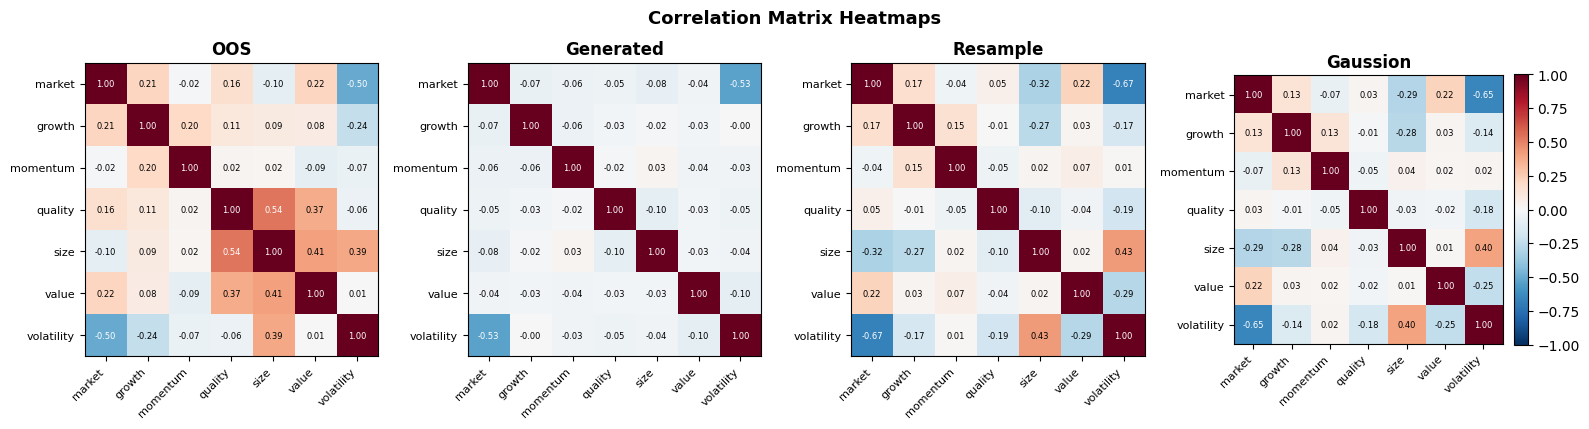

In [13]:
def corr_mat(data):
    return np.corrcoef(data, rowvar=False)

#corr_OOS  = corr_mat(train.drop(columns=['alpha']).values)
corr_OOS  = corr_mat(OOS)
corr_gen  = corr_mat(sampled)
corr_base = [(bname, corr_mat(bdata), bc) for bname, bdata, bc in baselines]

all_corrs = [('OOS', corr_OOS, 'steelblue'),
             ('Generated', corr_gen, '#2ca02c')] + corr_base

n = len(all_corrs)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.2))
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for ax, (name, corr, _) in zip(axes, all_corrs):
    im = ax.imshow(corr, cmap='RdBu_r', norm=norm)
    ax.set_xticks(range(len(FACTOR_NAMES)))
    ax.set_yticks(range(len(FACTOR_NAMES)))
    ax.set_xticklabels(FACTOR_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(FACTOR_NAMES, fontsize=8)
    ax.set_title(name, fontweight='bold')
    for ii in range(len(FACTOR_NAMES)):
        for jj in range(len(FACTOR_NAMES)):
            ax.text(jj, ii, f'{corr[ii, jj]:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(corr[ii, jj]) > 0.5 else 'black')

fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
fig.suptitle('Correlation Matrix Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print("Relative Frobenius Distance of Covariance Matrix")
print(f"  {'Generated':<16} {compute_cov(sampled, OOS):.4f}")
for bname, bdata, _ in baselines:
    print(f"  {bname:<16} {compute_cov(bdata, OOS):.4f}")

Relative Frobenius Distance of Covariance Matrix
  Generated        1.5855
  Resample         0.9548
  Gaussion         0.8401


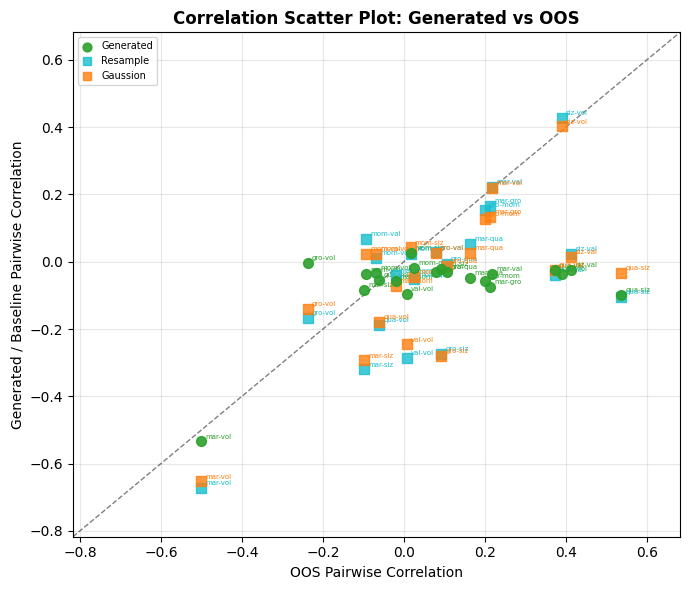

In [15]:
#QAQ Correlation Scatter Plot: Generated vs OOS
# Extract upper-triangular (off-diagonal) entries of each correlation matrix
import itertools

n_f = len(FACTOR_NAMES)
pair_labels = [f"{FACTOR_NAMES[i][:3]}-{FACTOR_NAMES[j][:3]}"
               for i, j in itertools.combinations(range(n_f), 2)]
idx_i, idx_j = zip(*itertools.combinations(range(n_f), 2))

def upper_tri(corr):
    return np.array([corr[i, j] for i, j in zip(idx_i, idx_j)])

corr_OOS_vec = upper_tri(corr_OOS)
corr_gen_vec = upper_tri(corr_gen)
corr_base_vecs = [(bname, upper_tri(bc_corr), bc)
                  for bname, bc_corr, bc in corr_base]

ANNOT_FS = 5
LEGEND_FS = 7
PT_SIZE   = 50

all_y_vecs = [corr_gen_vec] + [v for _, v, _ in corr_base_vecs]
lim = [min(corr_OOS_vec.min(), min(v.min() for v in all_y_vecs)),
       max(corr_OOS_vec.max(), max(v.max() for v in all_y_vecs))]
pad = (lim[1] - lim[0]) * 0.12 or 0.05
lim = [lim[0] - pad, lim[1] + pad]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)

# Generated
ax.scatter(corr_OOS_vec, corr_gen_vec, color='#2ca02c', s=PT_SIZE,
           marker='o', zorder=4, label='Generated', alpha=0.9)
for k, lbl in enumerate(pair_labels):
    ax.annotate(lbl, (corr_OOS_vec[k], corr_gen_vec[k]),
                fontsize=ANNOT_FS, xytext=(3, 2),
                textcoords='offset points', color='#2ca02c')

# Baselines
for bname, bvec, bc in corr_base_vecs:
    ax.scatter(corr_OOS_vec, bvec, color=bc, s=PT_SIZE,
               marker='s', zorder=3, label=bname, alpha=0.8)
    for k, lbl in enumerate(pair_labels):
        ax.annotate(lbl, (corr_OOS_vec[k], bvec[k]),
                    fontsize=ANNOT_FS, xytext=(3, 2),
                    textcoords='offset points', color=bc)

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('OOS Pairwise Correlation', fontsize=10)
ax.set_ylabel('Generated / Baseline Pairwise Correlation', fontsize=10)
ax.set_title('Correlation Scatter Plot: Generated vs OOS', fontweight='bold')
ax.legend(fontsize=LEGEND_FS, markerscale=0.9, handlelength=1.2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


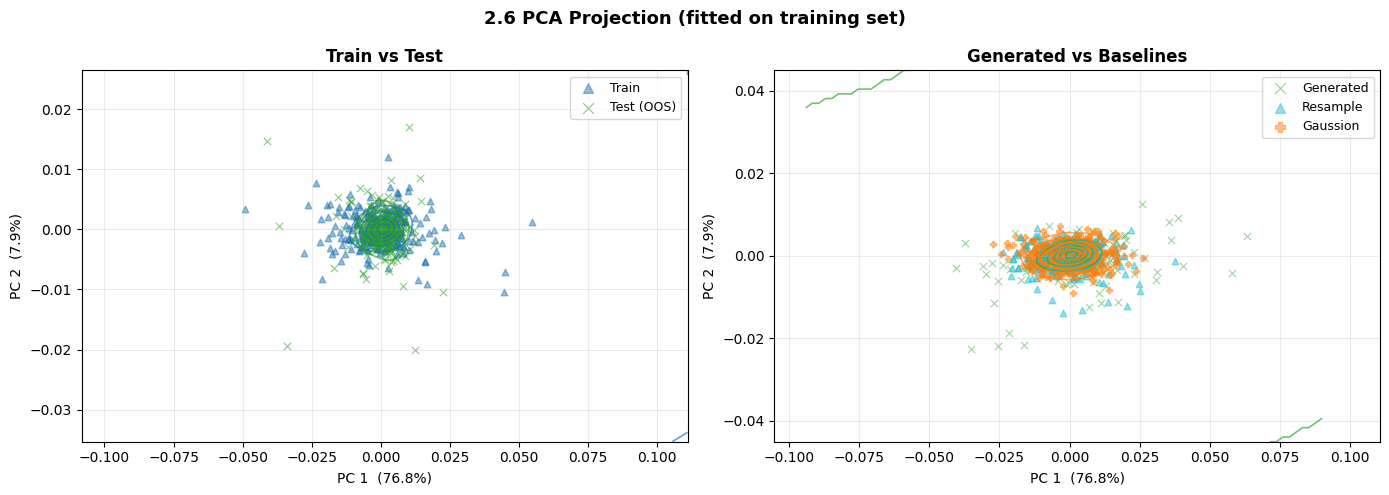

In [16]:
# PCA Projection
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

train_vals = train.drop(columns=['alpha']).values

pca = PCA(n_components=2)
pca.fit(train_vals)

train_pc = pca.transform(train_vals)
OOS_pc   = pca.transform(OOS)
gen_pc   = pca.transform(sampled)
base_pcs = [(bname, pca.transform(bdata), bc) for bname, bdata, bc in baselines]

xlab = f"PC 1  ({pca.explained_variance_ratio_[0]*100:.1f}%)"
ylab = f"PC 2  ({pca.explained_variance_ratio_[1]*100:.1f}%)"

N_SUB   = 300
C1, C2  = '#1a6faf', '#2ca02c'
MARKERS = ['^', 'P', 'D', 's']

def _sub(arr, n=N_SUB, seed=0):
    idx = np.random.default_rng(seed).choice(len(arr), size=min(n, len(arr)), replace=False)
    return arr[idx]

def _contour(ax, pc, color, levels=5, lw=1.2):
    kde  = gaussian_kde(pc.T)
    pad  = (pc.max(axis=0) - pc.min(axis=0)) * 0.15
    lo, hi = pc.min(axis=0) - pad, pc.max(axis=0) + pad
    xx, yy = np.mgrid[lo[0]:hi[0]:80j, lo[1]:hi[1]:80j]
    z = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contour(xx, yy, z, levels=levels, colors=[color], alpha=0.65, linewidths=lw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


_contour(ax1, train_pc, C1)
_contour(ax1, OOS_pc,   C2)
ax1.scatter(*_sub(train_pc, seed=0).T, c=C1, marker='^', s=22, alpha=0.45, label='Train')
ax1.scatter(*_sub(OOS_pc,   seed=1).T, c=C2, marker='x', s=28, alpha=0.55,
            label='Test (OOS)', linewidths=0.8)
ax1.set_xlabel(xlab); ax1.set_ylabel(ylab)
ax1.set_title('Train vs Test', fontweight='bold')
ax1.legend(fontsize=9, markerscale=1.5)
ax1.grid(True, alpha=0.25)

_contour(ax2, gen_pc, C2)
ax2.scatter(*_sub(gen_pc, seed=0).T, c=C2, marker='x', s=28, alpha=0.45,
            label='Generated', linewidths=0.8)
for i, (bname, bpc, bc) in enumerate(base_pcs):
    _contour(ax2, bpc, bc)
    ax2.scatter(*_sub(bpc, seed=i+1).T, c=bc, marker=MARKERS[i % len(MARKERS)],
                s=22, alpha=0.45, label=bname)
ax2.set_xlabel(xlab); ax2.set_ylabel(ylab)
ax2.set_title('Generated vs Baselines', fontweight='bold')
ax2.legend(fontsize=9, markerscale=1.5)
ax2.grid(True, alpha=0.25)

fig.suptitle('2.6 PCA Projection (fitted on training set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
jupyter nbconvert --to webpdf evaluation.ipynb

SyntaxError: invalid syntax (2507530244.py, line 1)